In [6]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('data/stud.csv')

In [8]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [9]:
X = df.drop(columns=['math_score'],axis=1)

In [10]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [11]:
y = df['math_score']

In [12]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [13]:
X = preprocessor.fit_transform(X)

In [14]:
X.shape

(1000, 19)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

Linear Regression Performance for test data:
MAE: 4.21476314247485
RMSE: 5.393993869732843
R2 Score: 0.8804332983749565
------------------------------
Ridge Regression Performance for test data:
MAE: 4.211100688014261
RMSE: 5.390387016935642
R2 Score: 0.8805931485028737
------------------------------
Lasso Regression Performance for test data:
MAE: 5.157881810347763
RMSE: 6.519694535667419
R2 Score: 0.8253197323627853
------------------------------
KNN Regressor Performance for test data:
MAE: 5.621
RMSE: 7.253040741647602
R2 Score: 0.7838129945787431
------------------------------
Decision Tree Regressor Performance for test data:
MAE: 6.375
RMSE: 8.030877909668407
R2 Score: 0.7349575734861411
------------------------------
Random Forest Regressor Performance for test data:
MAE: 4.639945833333333
RMSE: 5.979143748213916
R2 Score: 0.8530845934640585
------------------------------
AdaBoost Regressor Performance for test data:
MAE: 4.612031813533013
RMSE: 5.968166718850591
R2 Score: 0.85

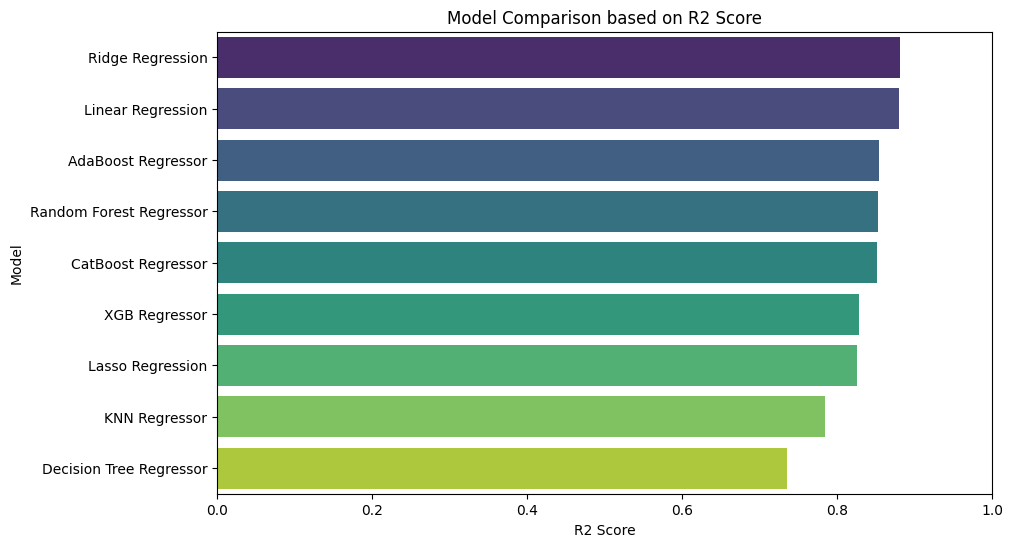

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "XGB Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=0)}
model_list = []
r2_list = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    mae, rmse, r2_square = evaluate_model(y_test, y_test_pred)
    print(f"{name} Performance for test data:")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2_square}")
    print("-" * 30)
    model_list.append(name)
    r2_list.append(r2_square)
results_df = pd.DataFrame({"Model": model_list, "R2 Score": r2_list})
results_df.sort_values(by="R2 Score", ascending=False, inplace=True)
plt.figure(figsize=(10, 6))
sns.barplot(x="R2 Score", y="Model", data=results_df, palette="viridis")
plt.title("Model Comparison based on R2 Score")
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

In [18]:
#Ridge Regression Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
}
ridge_grid = GridSearchCV(estimator=Ridge(), param_grid=ridge_params, cv=5, n_jobs=-1, verbose=2)
ridge_grid.fit(X_train, y_train)
print("Best Hyperparameters for Ridge Regression:", ridge_grid.best_params_)
best_ridge = ridge_grid.best_estimator_

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best Hyperparameters for Ridge Regression: {'alpha': 1, 'solver': 'sparse_cg'}


In [19]:
ridge_model = Ridge(alpha=1, solver='sparse_cg')
ridge_model.fit(X_train, y_train)
y_test_pred = ridge_model.predict(X_test)
score = r2_score(y_test, y_test_pred)*100
print(f"Ridge Regression accuracy after Hyperparameter Tuning: {score}")

Ridge Regression accuracy after Hyperparameter Tuning: 88.05920921362595


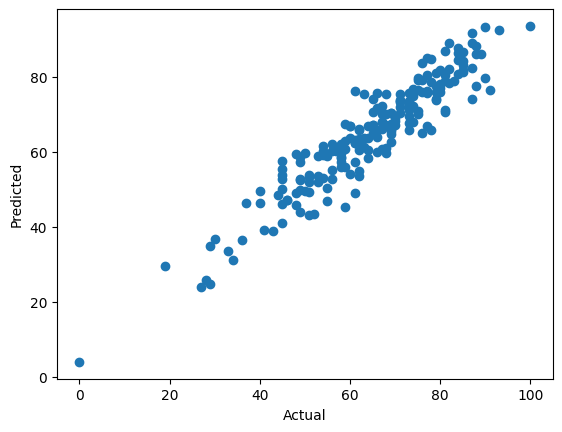

In [20]:
plt.scatter(y_test,y_test_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

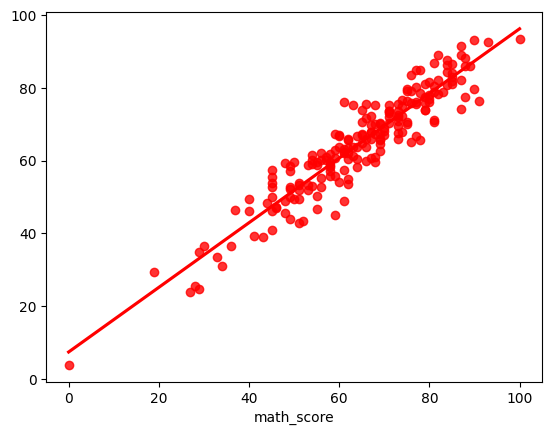

In [21]:
sns.regplot(x=y_test,y=y_test_pred,ci=None,color ='red');

In [22]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_test_pred,'Difference':y_test-y_test_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.399041,14.600959
737,53,58.843813,-5.843813
740,80,76.989204,3.010796
660,74,76.808004,-2.808004
411,84,87.615726,-3.615726
...,...,...,...
408,52,43.492938,8.507062
332,62,62.168464,-0.168464
208,74,67.912473,6.087527
613,65,67.061573,-2.061573
